In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
acn_clean = pd.read_csv("acn_cleaned.csv")

In [23]:
# Dataset Overview

print(acn_clean.shape)

acn_clean.describe().T

(14979, 33)


,count,mean,std,min,25%,50%,75%,max
clusterID,14979.0,39.000000,0.000000,39.000000,39.000000,39.000000,39.000000,39.000000
kWhDelivered,14979.0,9.010819,7.055499,0.501000,4.018000,7.447000,13.204000,69.373000
siteID,14979.0,2.000000,0.000000,2.000000,2.000000,2.000000,2.000000,2.000000
WhPerMile,14979.0,345.777822,38.805248,200.000000,346.000000,346.000000,346.000000,600.000000
kWhRequested,14979.0,3.290176,10.473524,0.000000,0.000000,0.000000,0.000000,150.000000
milesRequested,14979.0,10.345083,33.517409,0.000000,0.000000,0.000000,0.000000,300.000000
minutesAvailable,14979.0,48.936912,138.506656,0.000000,0.000000,0.000000,0.000000,1078.000000
paymentRequired,14979.0,0.148942,0.356043,0.000000,0.000000,0.000000,0.000000,1.000000
userID_available,14979.0,0.148942,0.356043,0.000000,0.000000,0.000000,0.000000,1.000000
kWhRequested_available,14979.0,0.148942,0.356043,0.000000,0.000000,0.000000,0.000000,1.000000


In [30]:
print("Rows, Columns:", acn_clean.shape)

print("Total Missing Values:",
      acn_clean.isnull().sum().sum())

print("Duplicate Sessions:",
      acn_clean['sessionID'].duplicated().sum())

print("Min Charging Duration:",
      acn_clean['charging_duration_hr'].min())

print("Min Session Duration:",
      acn_clean['session_duration_hr'].min())

Rows, Columns: (14979, 33)
Total Missing Values: 8
Duplicate Sessions: 0
Min Charging Duration: 0.0019444444444444
Min Session Duration: 0.0875


In [24]:
# Checking For Duplicate Sessions

acn_clean['sessionID'].duplicated().sum()

np.int64(0)

# The cleaned ACN dataset contains 14,979 charging sessions and 33 analytical features. Data quality is very high, with only 8 remaining missing values across the entire dataset and no duplicate session records.

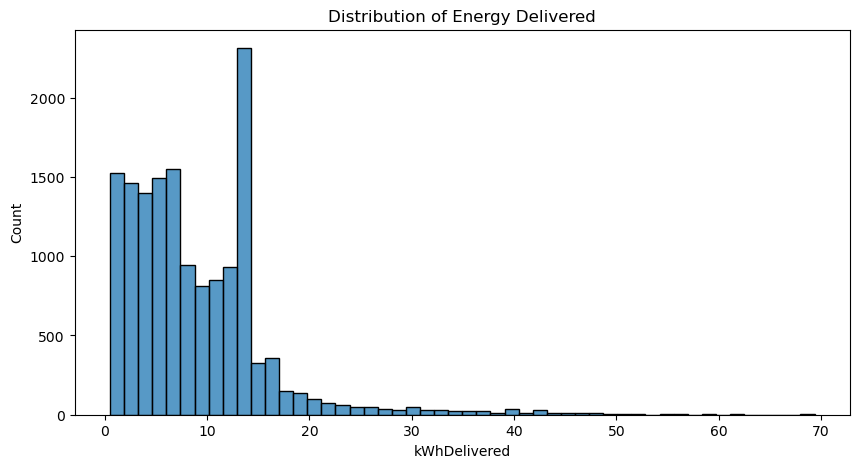

In [25]:
# Energy Delivered Distribution

plt.figure(figsize=(10,5))
sns.histplot(
    acn_clean['kWhDelivered'],
    bins=50
)
plt.title("Distribution of Energy Delivered")
plt.show()

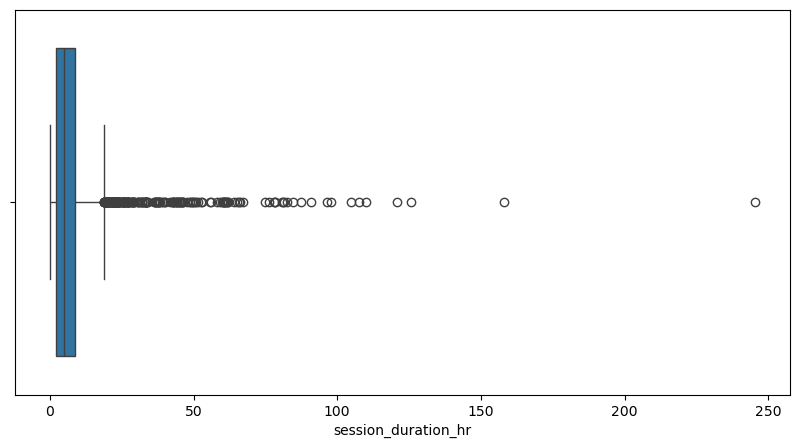

In [26]:
# Session Duration Distribution

plt.figure(figsize=(10,5))

sns.boxplot(
    x=acn_clean['session_duration_hr']
)

plt.show()

In [27]:
# Charging vs Idle Time

acn_clean[
    ['charging_duration_hr',
     'idle_time_hr']
].describe()

,charging_duration_hr,idle_time_hr
count,14979.000000,14979.000000
mean,3.239827,2.680316
std,3.184603,5.365174
min,0.001944,0.000000
25%,1.274583,0.001389
50%,2.245000,0.731944
75%,4.245556,4.176944
max,104.428333,156.121389


# Vehicles spend an average of 3.24 hours actively charging but remain connected for an additional 2.68 hours after charging completion. This means idle occupancy represents approximately 83% of active charging time (2.68 / 3.24), indicating that charger availability is constrained not only by energy demand but also by post-charging parking behavior.

# This finding strongly supports the introduction of idle-time penalties or dynamic tariffs to improve charger turnover and reduce congestion.

# While most sessions exhibit limited idle occupancy, a subset of sessions shows extremely long post-charging occupancy durations, reaching more than 156 hours. These sessions likely represent charger blocking behavior and should be treated as operational outliers during optimization analysis.

In [34]:
# Top Stations

acn_clean['stationID'] \
    .value_counts() \
    .head(20)

stationID
2-39-139-28    687
2-39-131-30    560
2-39-129-17    526
2-39-127-19    524
2-39-125-21    501
2-39-138-29    500
2-39-89-25     476
2-39-123-23    453
2-39-130-31    438
2-39-79-380    405
2-39-128-18    387
2-39-79-379    386
2-39-79-377    379
2-39-78-365    373
2-39-91-437    369
2-39-78-366    356
2-39-124-22    347
2-39-126-20    346
2-39-88-24     344
2-39-95-27     337
Name: count, dtype: int64

# Charging demand is unevenly distributed across stations. The busiest station recorded 687 sessions, significantly exceeding many other chargers in the network. This suggests that congestion is likely localized rather than uniformly distributed across all charging infrastructure.

# Dynamic pricing should be targeted at specific high-demand stations rather than applied uniformly across the network.

In [36]:
# Time Coverage

print(
    acn_clean['connectionTime'].min()
)

print(
    acn_clean['connectionTime'].max()
)

2018-04-25 11:08:04
2018-12-16 03:01:46


<Axes: title={'center': 'Monthly Energy Delivered'}, xlabel='connectionTime'>

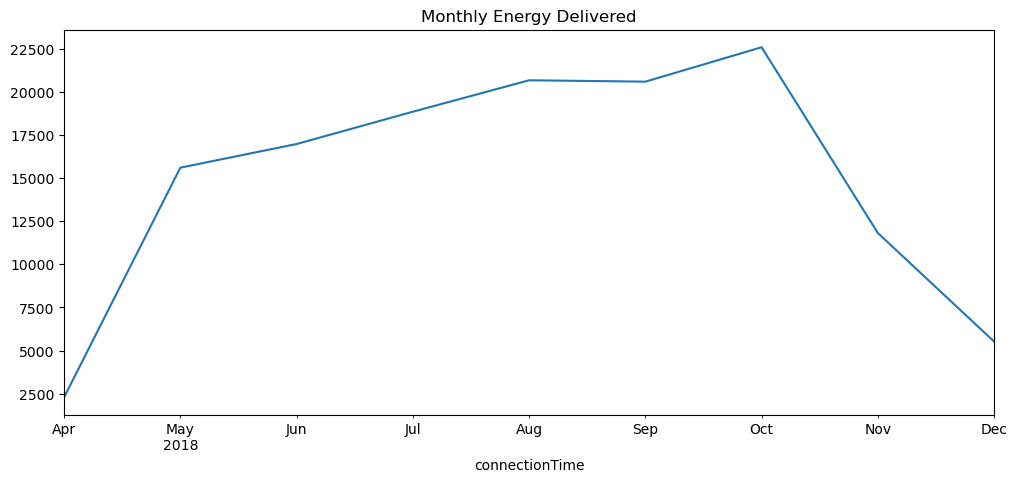

In [50]:
# Monthly Demand

monthly = (
    acn_clean
    .groupby(
        acn_clean['connectionTime']
        .dt.to_period('M')
    )['kWhDelivered']
    .sum()
)

monthly.plot(
    figsize=(12,5),
    title='Monthly Energy Delivered'
)

# Energy Delivered is highest during the month of October. 

In [51]:
date_cols = [
    'connectionTime',
    'disconnectTime',
    'doneChargingTime'
]

for col in date_cols:
    if col in acn_clean.columns:
        acn_clean[col] = pd.to_datetime(
            acn_clean[col],
            errors='coerce'
        )

In [52]:
acn_clean[date_cols].dtypes

connectionTime      datetime64[ns]
disconnectTime      datetime64[ns]
doneChargingTime    datetime64[ns]
dtype: object

In [53]:
monthly = (
    acn_clean.groupby(
        pd.Grouper(
            key='connectionTime',
            freq='M'
        )
    )['kWhDelivered']
    .sum()
)

monthly.head()

/var/folders/jp/mwm996tj3ts__35bq5fx0g1r0000gn/T/ipykernel_3701/3899807002.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(


connectionTime
2018-04-30     2288.760013
2018-05-31    15612.990466
2018-06-30    16984.573907
2018-07-31    18859.196142
2018-08-31    20684.045590
Freq: ME, Name: kWhDelivered, dtype: float64

In [49]:
# Outlier Detection

Q1 = acn_clean['kWhDelivered'].quantile(0.25)
Q3 = acn_clean['kWhDelivered'].quantile(0.75)

IQR = Q3 - Q1

upper = Q3 + 1.5*IQR

outliers = (
    acn_clean['kWhDelivered'] > upper
).sum()

print(outliers)

399


# Approximately 399 charging sessions fall outside the typical energy-delivery range based on the IQR method. These sessions represent unusual charging behavior and may correspond to high-capacity charging events, extended dwell times, or anomalous operational conditions.

# These observations should be investigated further before training forecasting models, as they may disproportionately influence predictions.

# Idle Percentage

In [107]:
acn_clean['idle_pct'] = (
    acn_clean['idle_time_hr']
    /
    acn_clean['session_duration_hr']
)

In [108]:
acn_clean['idle_pct'].describe()

count    14979.000000
mean         0.307449
std          0.324714
min          0.000000
25%          0.001345
50%          0.182823
75%          0.610322
max          0.999843
Name: idle_pct, dtype: float64

In [117]:
# Idle Occupancy Ratio

idle_ratio = (
    acn_clean['idle_time_hr'].sum()
    /
    acn_clean['session_duration_hr'].sum()
) * 100

print(idle_ratio)

45.28047554355314


# Approximately 45.3% of total charger occupancy time is idle rather than active charging.

sns.histplot(
    acn_clean['idle_pct'],
    bins=50
)

# Charging Demand Analysis

In [72]:
hourly_sessions = (
    acn_clean
    .groupby('hour')
    .size()
    .sort_values(ascending=False)
)

display(hourly_sessions.head(10))

peak_hour = hourly_sessions.idxmax()

print(f"Peak Hour: {peak_hour}")
print(f"Sessions: {hourly_sessions.max()}")

hour
15    2567
16    2037
14    1088
17    1017
1      878
0      766
20     713
2      711
19     702
23     641
dtype: int64

Peak Hour: 15
Sessions: 2567


# Hours 14-17 are periods of most congestion.

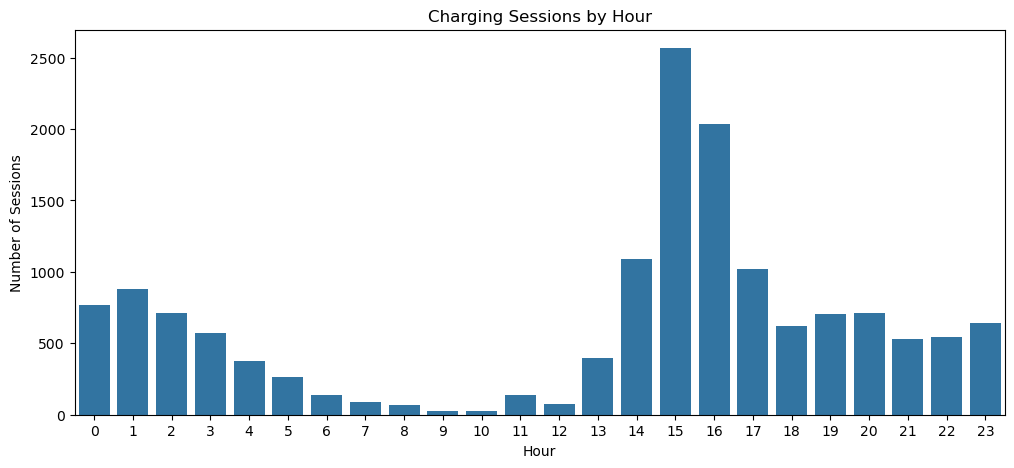

In [73]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=hourly_sessions.index,
    y=hourly_sessions.values
)

plt.title("Charging Sessions by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Sessions")
plt.show()

# Interpretation - The charging demand is highly concentrated during a few specific hours of the day. This indicates that users exhibit synchronized charging behavior, likely influenced by workplace arrival patterns. From a tariff optimization perspective, these peak periods are ideal candidates for dynamic pricing. Increasing tariffs during peak demand windows may help reduce congestion while shifting flexible users to lower-demand periods.

# Station Analysis

In [74]:
peak_data = acn_clean[
    acn_clean['hour'] == peak_hour
]

top_peak_stations = (
    peak_data['stationID']
    .value_counts()
    .head(10)
)

display(top_peak_stations)

stationID
2-39-89-25     101
2-39-78-361     94
2-39-78-366     87
2-39-91-437     87
2-39-88-24      86
2-39-78-360     85
2-39-78-363     82
2-39-78-365     80
2-39-79-382     76
2-39-90-26      76
Name: count, dtype: int64

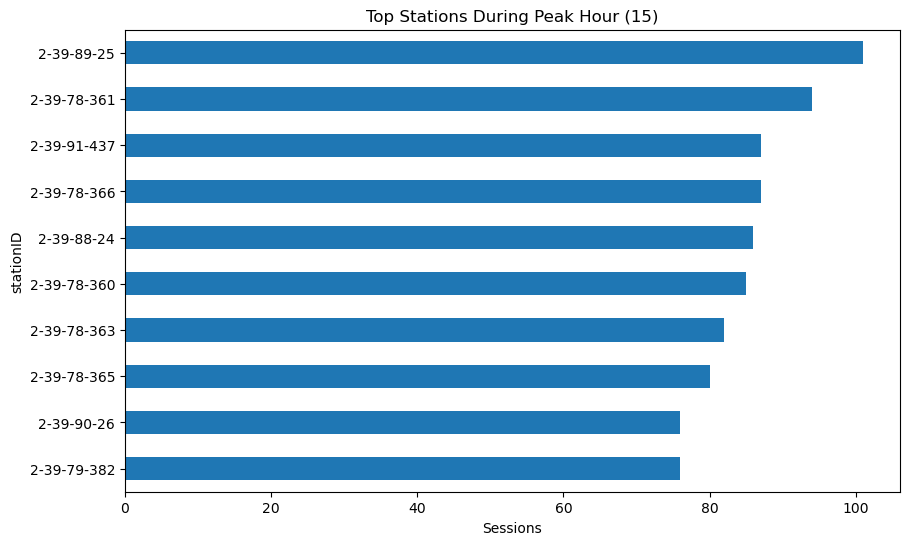

In [75]:
plt.figure(figsize=(10,6))

top_peak_stations.sort_values().plot(
    kind='barh'
)

plt.title(f'Top Stations During Peak Hour ({peak_hour})')
plt.xlabel('Sessions')
plt.show()

In [76]:
# Day-of-Week Demand

dow_summary = (
    acn_clean
    .groupby('day_of_week')
    .agg(
        sessions=('sessionID','count'),
        total_kwh=('kWhDelivered','sum')
    )
)

display(dow_summary)

,sessions,total_kwh
day_of_week,,
0,2221,21546.670675
1,2451,21690.800536
2,2473,21482.789039
3,2503,20831.644450
4,2538,21809.892167
5,1573,15836.083296
6,1220,11775.179444


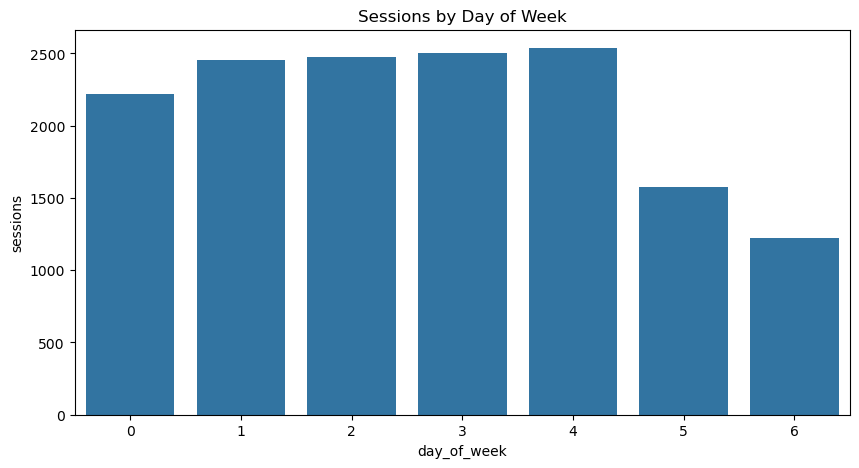

In [77]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=dow_summary.index,
    y=dow_summary['sessions']
)

plt.title("Sessions by Day of Week")
plt.show()

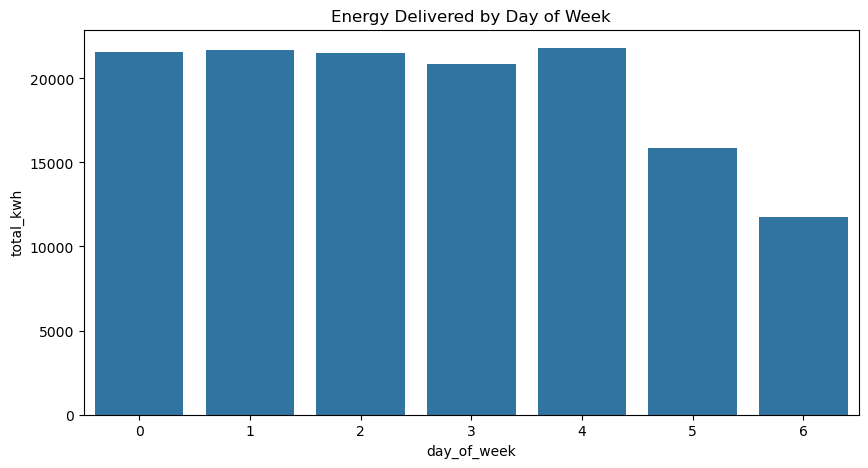

In [78]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=dow_summary.index,
    y=dow_summary['total_kwh']
)

plt.title("Energy Delivered by Day of Week")
plt.show()

In [79]:
# Day-of-Month Analysis

dom_summary = (
    acn_clean
    .groupby('day')
    ['kWhDelivered']
    .sum()
)

display(dom_summary.head())

day
1    4371.556665
2    4144.887293
3    3976.727243
4    4213.973344
5    4779.598696
Name: kWhDelivered, dtype: float64

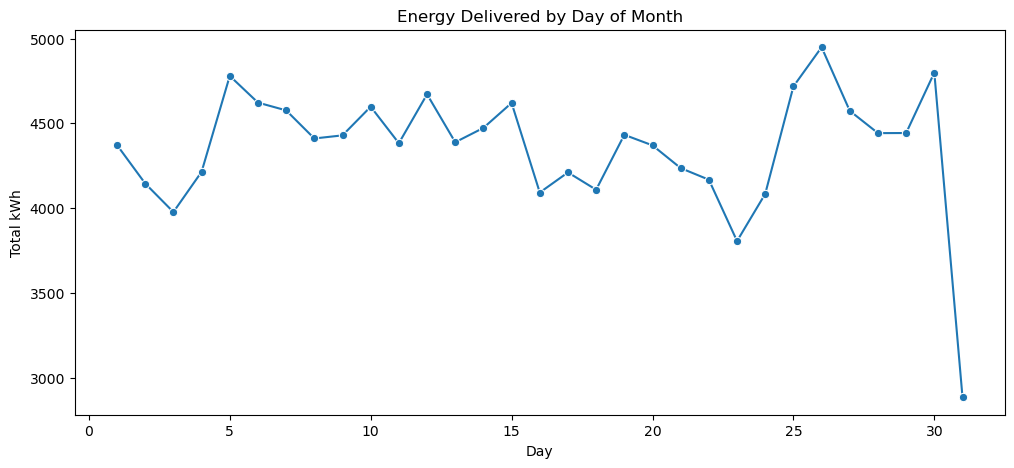

In [80]:
plt.figure(figsize=(12,5))

sns.lineplot(
    x=dom_summary.index,
    y=dom_summary.values,
    marker='o'
)

plt.title("Energy Delivered by Day of Month")
plt.xlabel("Day")
plt.ylabel("Total kWh")
plt.show()

In [81]:
# Monthly Growth Analysis

monthly_summary = (
    acn_clean
    .groupby(
        acn_clean['connectionTime']
        .dt.to_period('M')
    )
    .agg(
        monthly_sessions=('sessionID','count'),
        monthly_kwh=('kWhDelivered','sum'),
        monthly_avg_kwh=('kWhDelivered','mean'),
        monthly_avg_duration=('session_duration_hr','mean')
    )
)

display(monthly_summary)

,monthly_sessions,monthly_kwh,monthly_avg_kwh,monthly_avg_duration
connectionTime,,,,
2018-04,258,2288.760013,8.871163,6.485102
2018-05,1763,15612.990466,8.855922,6.292664
2018-06,1854,16984.573907,9.161043,6.273304
2018-07,2043,18859.196142,9.231129,5.730022
2018-08,2430,20684.045590,8.511953,5.579027
2018-09,2316,20604.341965,8.896521,5.361274
2018-10,2402,22600.799144,9.409159,5.956104
2018-11,1331,11818.819380,8.879654,6.628541
2018-12,582,5519.533000,9.483734,5.943301


# The dataset spans nearly eight months of charging activity, covering multiple seasons and operational cycles. This duration is sufficient to capture recurring temporal patterns and train forecasting models capable of learning demand fluctuations across time.

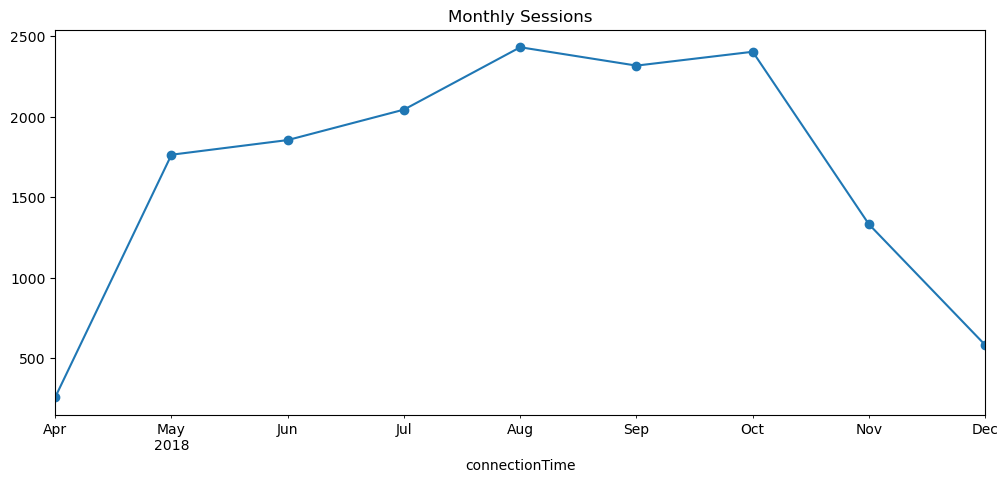

In [82]:
monthly_summary['monthly_sessions'].plot(
    figsize=(12,5),
    marker='o'
)

plt.title("Monthly Sessions")
plt.show()

# No. of sessions peaked during August and October

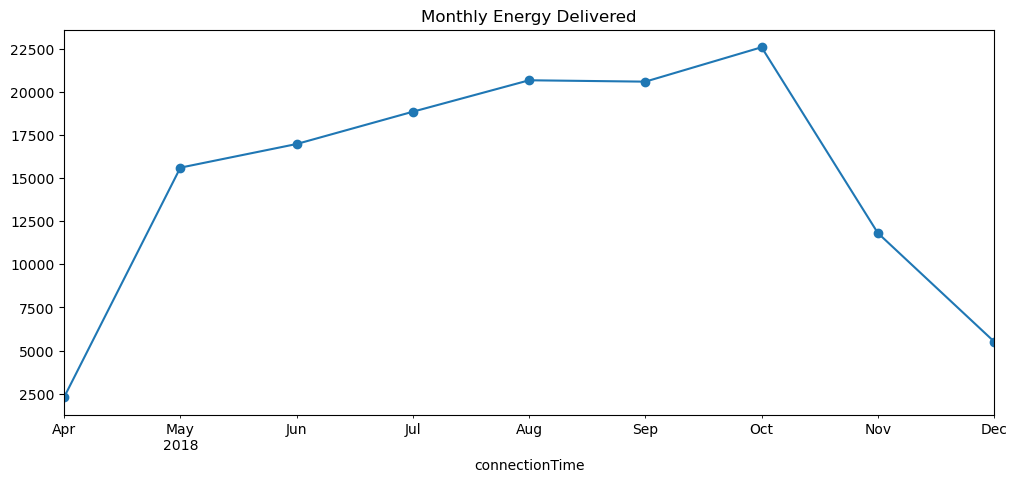

In [83]:
monthly_summary['monthly_kwh'].plot(
    figsize=(12,5),
    marker='o'
)

plt.title("Monthly Energy Delivered")
plt.show()

# Energy Delivered peaked during August and October

# Station Ranking

In [85]:
station_summary = (
    acn_clean
    .groupby('stationID')
    .agg(
        sessions=('sessionID','count'),
        total_kwh=('kWhDelivered','sum'),
        avg_kwh=('kWhDelivered','mean'),
        avg_idle=('idle_time_hr','mean'),
        avg_duration=('session_duration_hr','mean'),
        utilization=('utilization_ratio','mean')
    )
)

display(
    station_summary
    .sort_values(
        'total_kwh',
        ascending=False
    )
    .head(20)
)

,sessions,total_kwh,avg_kwh,avg_idle,avg_duration,utilization
stationID,,,,,,
2-39-139-28,687,5913.095654,8.607126,1.836952,4.736001,0.775888
2-39-131-30,560,5104.932558,9.115951,2.348450,5.427736,0.746463
2-39-129-17,526,4599.352634,8.744016,1.935660,4.733907,0.764191
2-39-127-19,524,4500.529416,8.588797,1.875702,4.608514,0.766652
2-39-138-29,500,4261.644058,8.523288,1.708748,4.545554,0.770648
2-39-89-25,476,4212.562333,8.849921,2.835302,5.357955,0.692512
2-39-91-437,369,4200.105124,11.382399,3.421914,6.691407,0.636925
2-39-79-377,379,4021.641348,10.611191,3.001638,6.579156,0.667790
2-39-125-21,501,3985.560093,7.955210,1.815145,4.066532,0.758590


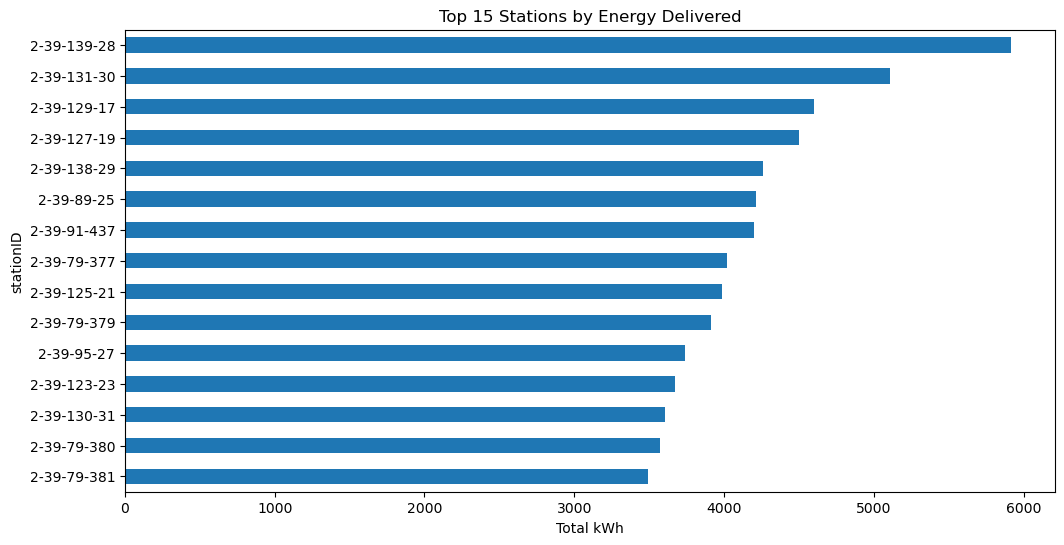

In [86]:
plt.figure(figsize=(12,6))

(
station_summary
.sort_values('total_kwh',
             ascending=False)
.head(15)
.sort_values('total_kwh')
['total_kwh']
.plot(kind='barh')
)

plt.title(
    "Top 15 Stations by Energy Delivered"
)

plt.xlabel("Total kWh")
plt.show()

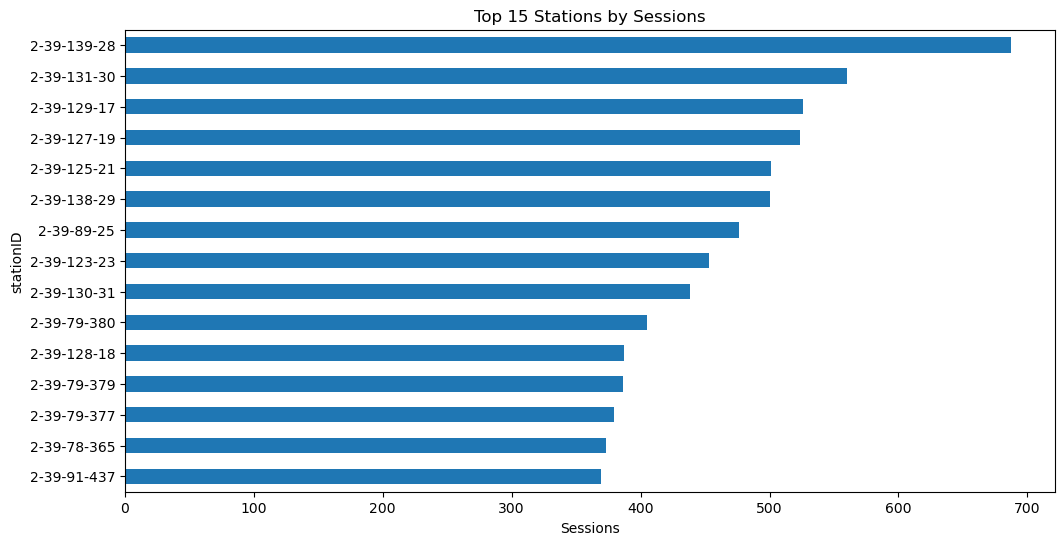

In [87]:
plt.figure(figsize=(12,6))

(
station_summary
.sort_values('sessions',
             ascending=False)
.head(15)
.sort_values('sessions')
['sessions']
.plot(kind='barh')
)

plt.title(
    "Top 15 Stations by Sessions"
)

plt.xlabel("Sessions")
plt.show()

In [118]:
# Demand Concentration

station_share = (
    acn_clean.groupby('stationID')['kWhDelivered']
    .sum()
    .sort_values(ascending=False)
)

top10_share = (
    station_share.head(10).sum()
    /
    station_share.sum()
) * 100

print(top10_share)

33.12616632352871


# Top 10 stations account for 33% of total network energy demand.

In [ ]:
# Idle Time Ranking

In [88]:
idle_rank = (
    station_summary
    .sort_values(
        'avg_idle',
        ascending=False
    )
)

display(
    idle_rank.head(20)
)

,sessions,total_kwh,avg_kwh,avg_idle,avg_duration,utilization
stationID,,,,,,
2-39-79-379,386,3911.977000,10.134655,6.139231,10.005604,0.577160
2-39-79-378,330,3035.030350,9.197062,5.236455,9.012912,0.578559
2-39-79-376,287,2749.808906,9.581216,4.127515,7.783930,0.635369
2-39-79-382,249,2296.729728,9.223814,3.882768,7.912118,0.596339
2-39-92-442,236,2230.372787,9.450732,3.858123,7.006880,0.552806
2-39-95-27,337,3736.646728,11.087972,3.750834,7.217402,0.619196
2-39-124-558,85,613.389000,7.216341,3.718866,6.617196,0.560175
2-39-79-383,321,3195.019058,9.953330,3.666618,7.172393,0.594732
2-39-91-437,369,4200.105124,11.382399,3.421914,6.691407,0.636925


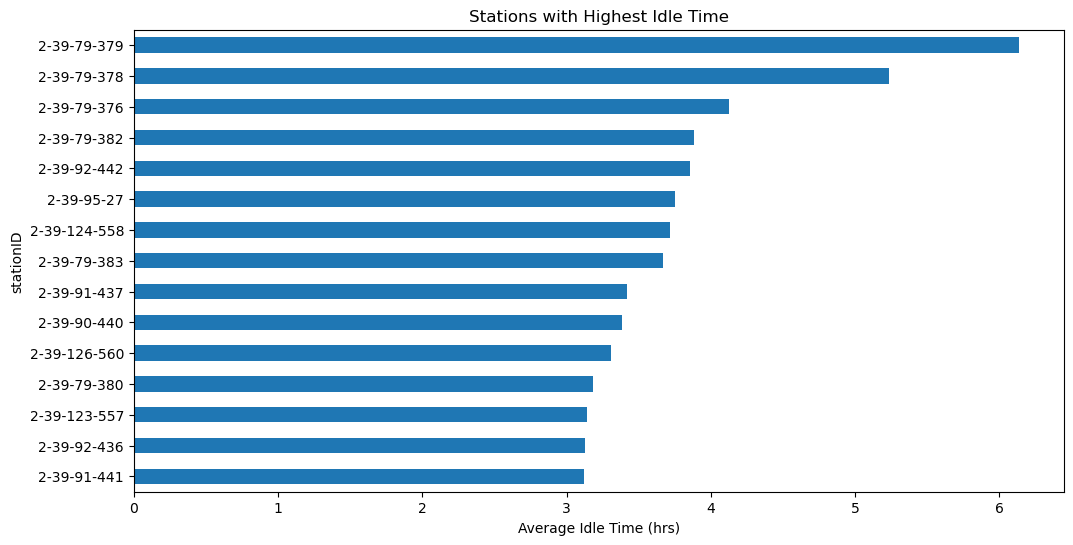

In [89]:
plt.figure(figsize=(12,6))

(
idle_rank
.head(15)
.sort_values('avg_idle')
['avg_idle']
.plot(kind='barh')
)

plt.title(
    "Stations with Highest Idle Time"
)

plt.xlabel("Average Idle Time (hrs)")
plt.show()

In [ ]:
# Efficiency Matrix

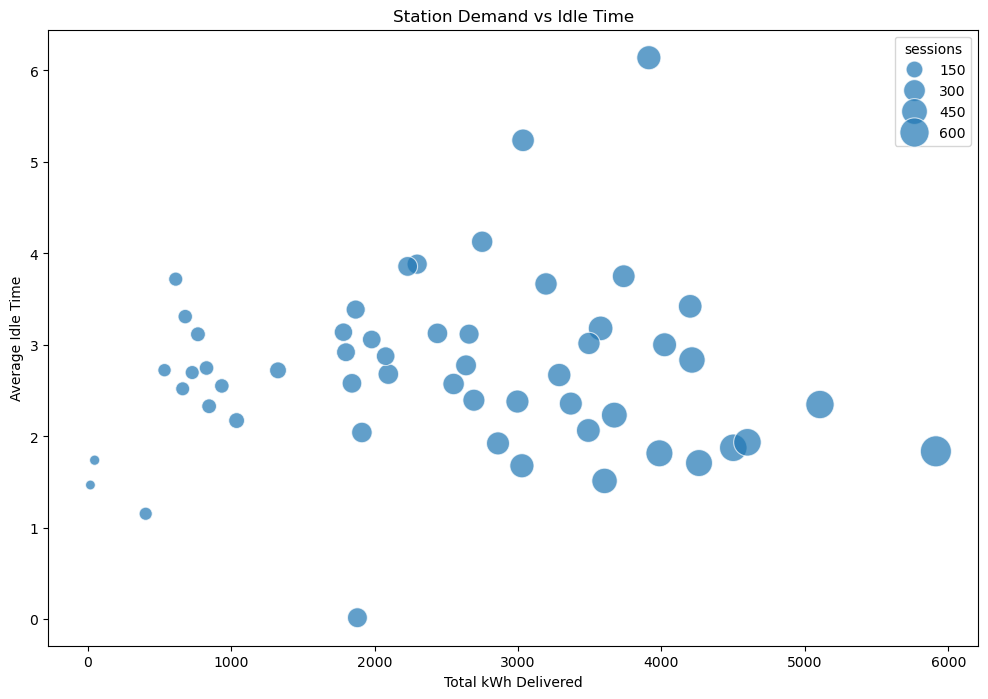

In [90]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=station_summary,
    x='total_kwh',
    y='avg_idle',
    size='sessions',
    sizes=(50,500),
    alpha=0.7
)

plt.title(
    'Station Demand vs Idle Time'
)

plt.xlabel(
    'Total kWh Delivered'
)

plt.ylabel(
    'Average Idle Time'
)

plt.show()

In [ ]:
# Hour × Day Heatmap

<Axes: xlabel='hour', ylabel='day_of_week'>

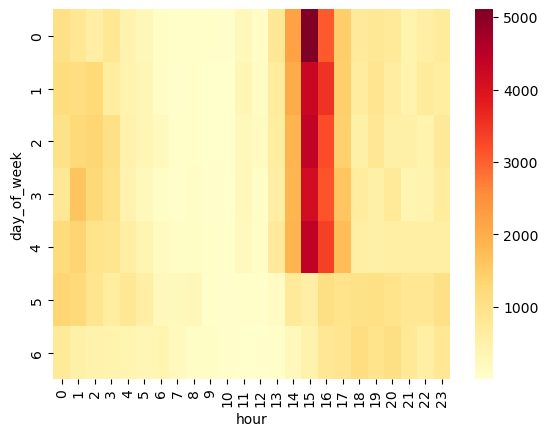

In [91]:
pivot = acn_clean.pivot_table(
    values='kWhDelivered',
    index='day_of_week',
    columns='hour',
    aggfunc='sum'
)

sns.heatmap(pivot, cmap='YlOrRd')

# Shows:Peak demand hours, Weekday vs weekend differences, Demand concentration

# Insight: Dynamic pricing should target specific hours, not entire days.

In [ ]:
# Idle Percentage by Hour

<Axes: xlabel='hour'>

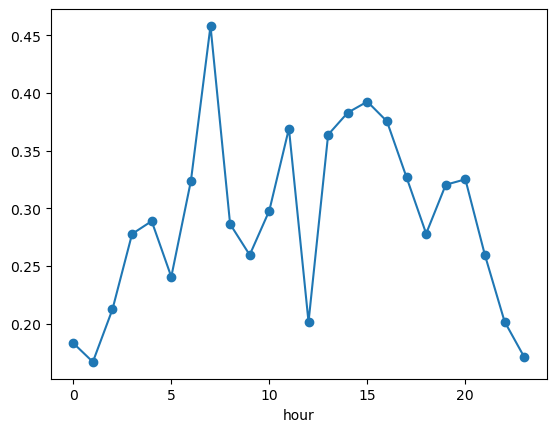

In [101]:
acn_clean['idle_pct'] = (
    acn_clean['idle_time_hr']
    /
    acn_clean['session_duration_hr']
)

hourly_idle = (
    acn_clean.groupby('hour')
    ['idle_pct']
    .mean()
)

hourly_idle.plot(marker='o')

In [104]:
# Correlation Heatmap

<Axes: >

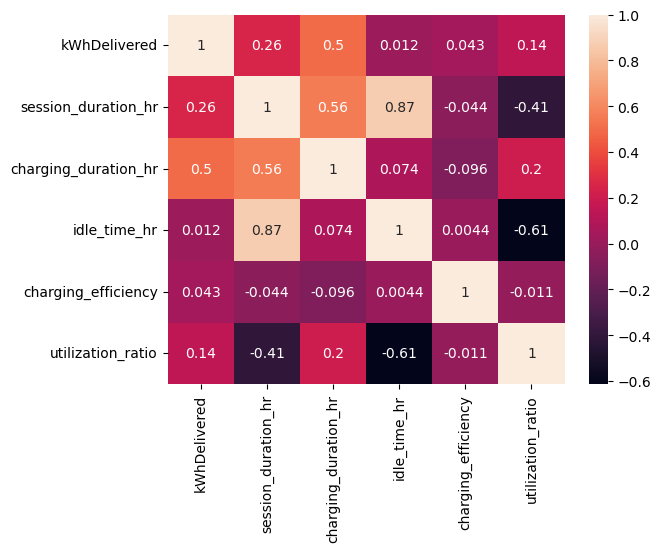

In [105]:
features = [
    'kWhDelivered',
    'session_duration_hr',
    'charging_duration_hr',
    'idle_time_hr',
    'charging_efficiency',
    'utilization_ratio'
]

sns.heatmap(
    acn_clean[features].corr(),
    annot=True
)

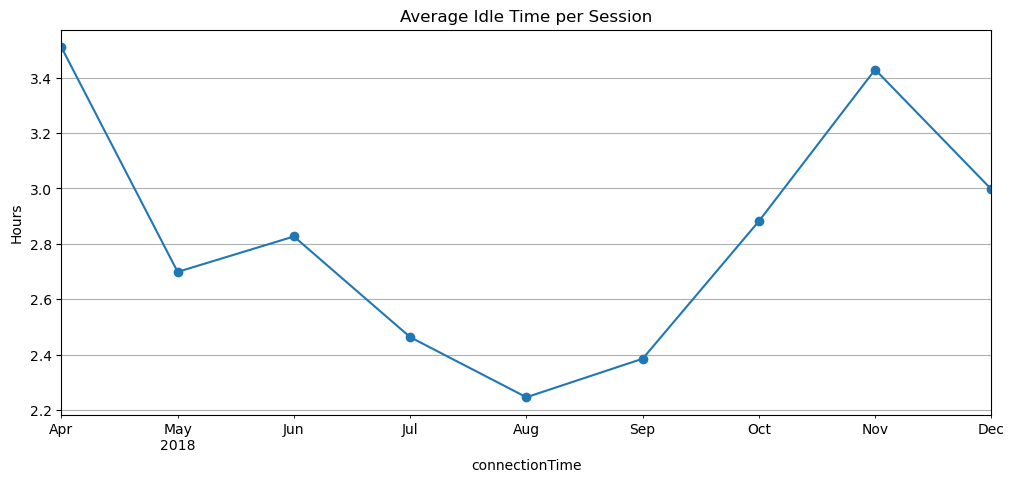

In [63]:
# Average Idle Time

plt.figure(figsize=(12,5))

monthly_summary['monthly_avg_idle'].plot(
    marker='o'
)

plt.title('Average Idle Time per Session')
plt.ylabel('Hours')
plt.grid(True)
plt.show()

In [64]:
# Utilization Growth Proxy

monthly_summary['kwh_per_hour'] = (
    monthly_summary['monthly_avg_kwh']
    /
    monthly_summary['monthly_avg_duration']
)

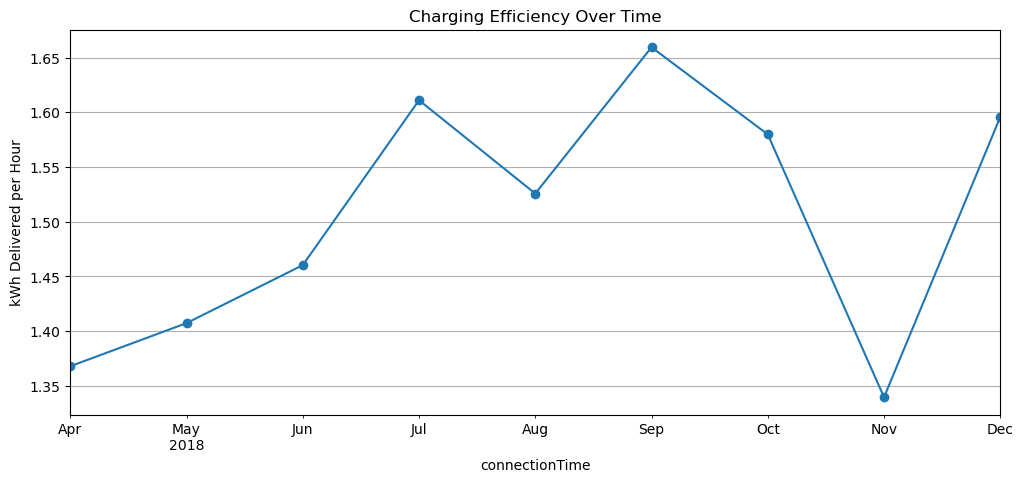

In [65]:
plt.figure(figsize=(12,5))

monthly_summary['kwh_per_hour'].plot(
    marker='o'
)

plt.title('Charging Efficiency Over Time')
plt.ylabel('kWh Delivered per Hour')
plt.grid(True)
plt.show()

In [66]:
monthly_summary.round(2)

,monthly_sessions,monthly_kwh,monthly_avg_kwh,monthly_avg_duration,monthly_avg_idle,kwh_per_hour
connectionTime,,,,,,
2018-04,258,2288.76,8.87,6.49,3.51,1.37
2018-05,1763,15612.99,8.86,6.29,2.70,1.41
2018-06,1854,16984.57,9.16,6.27,2.83,1.46
2018-07,2043,18859.20,9.23,5.73,2.46,1.61
2018-08,2430,20684.05,8.51,5.58,2.25,1.53
2018-09,2316,20604.34,8.90,5.36,2.39,1.66
2018-10,2402,22600.80,9.41,5.96,2.88,1.58
2018-11,1331,11818.82,8.88,6.63,3.43,1.34
2018-12,582,5519.53,9.48,5.94,3.00,1.60


In [114]:
# User Behavior

user_behavior = (
    acn_clean
    .groupby('userID_available')
    .agg(
        avg_kwh=('kWhDelivered','mean'),
        avg_idle=('idle_time_hr','mean'),
        avg_duration=('session_duration_hr','mean')
    )
)

display(user_behavior)

,avg_kwh,avg_idle,avg_duration
userID_available,,,
0,8.313276,2.535857,5.713715
1,12.996602,3.505760,7.094453


In [115]:
# Fulfillment Ratio

acn_clean['fulfillment_ratio'] = (
    acn_clean['kWhDelivered']
    /
    acn_clean['kWhRequested']
)

In [116]:
acn_clean[
    acn_clean['kWhRequested'] > 0
]

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,...,day_of_week,month,day,week,year,weekend,charging_efficiency,utilization_ratio,idle_pct,fulfillment_ratio
222,5bc915caf9af8b0dad3c0660,39.0,2018-04-30 15:07:49,2018-05-01 00:27:55,2018-05-01 00:27:51,47.808,2_39_88_24_2018-04-30 15:07:48.608581,2.0,CA-314,2-39-88-24,...,0,4,30,18,2018,0,5.121981,0.999881,0.000119,0.803496
581,5bc917d0f9af8b0dc677b8bb,39.0,2018-05-07 14:38:18,2018-05-08 01:15:01,2018-05-08 01:14:53,27.683,2_39_139_28_2018-05-07 14:38:17.789708,2.0,CA-303,2-39-139-28,...,0,5,7,19,2018,0,2.609211,0.999791,0.000209,3.460375
840,5bc9190ff9af8b0dc677b9c1,39.0,2018-05-11 15:17:01,2018-05-12 00:18:43,2018-05-11 23:05:56,17.485,2_39_88_24_2018-05-11 15:17:00.986127,2.0,CA-314,2-39-88-24,...,4,5,11,19,2018,0,2.237285,0.865639,0.134361,0.999143
953,5bc919c3f9af8b0dc677ba32,39.0,2018-05-14 13:50:26,2018-05-14 23:09:45,2018-05-14 20:43:40,11.795,2_39_79_380_2018-05-14 13:50:25.765617,2.0,CA-489,2-39-79-380,...,0,5,14,20,2018,0,1.712592,0.738818,0.261182,1.474375
1001,5bc919c3f9af8b0dc677ba62,39.0,2018-05-15 00:06:39,2018-05-15 01:13:58,2018-05-15 00:39:01,3.076,2_39_139_28_2018-05-15 00:06:39.142568,2.0,CA-303,2-39-139-28,...,1,5,15,20,2018,0,5.702163,0.480812,0.519188,0.615200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14974,5c2e8c38f9af8b13dab07c37,39.0,2018-12-15 22:22:57,2018-12-15 23:36:35,2018-12-15 23:23:26,6.554,2_39_138_29_2018-12-15 22:22:57.474988,2.0,CA-304,2-39-138-29,...,5,12,15,50,2018,1,6.501626,0.821412,0.178588,0.305976
14975,5c2e8c38f9af8b13dab07c38,39.0,2018-12-15 23:02:07,2018-12-16 13:22:44,2018-12-16 08:29:42,58.873,2_39_79_380_2018-12-15 23:02:06.844589,2.0,CA-489,2-39-79-380,...,5,12,15,50,2018,1,6.223544,0.659508,0.340492,0.621810
14976,5c2e8c38f9af8b13dab07c39,39.0,2018-12-15 23:06:40,2018-12-15 23:49:53,2018-12-15 23:49:44,4.356,2_39_92_436_2018-12-15 23:06:40.146753,2.0,CA-318,2-39-92-436,...,5,12,15,50,2018,1,6.068731,0.996529,0.003471,0.504167
14977,5c2e8c38f9af8b13dab07c3a,39.0,2018-12-15 23:34:41,2018-12-16 06:27:36,2018-12-16 01:22:27,5.212,2_39_126_20_2018-12-15 23:34:40.796183,2.0,CA-310,2-39-126-20,...,5,12,15,50,2018,1,2.901825,0.260989,0.739011,0.782583


In [119]:
registered = user_behavior.loc[1]
anonymous = user_behavior.loc[0]

print(
    ((registered['avg_kwh'] - anonymous['avg_kwh'])
     / anonymous['avg_kwh']) * 100
)

56.335503968072395


# Registered users consume approximately 56% more energy per charging session than anonymous users.

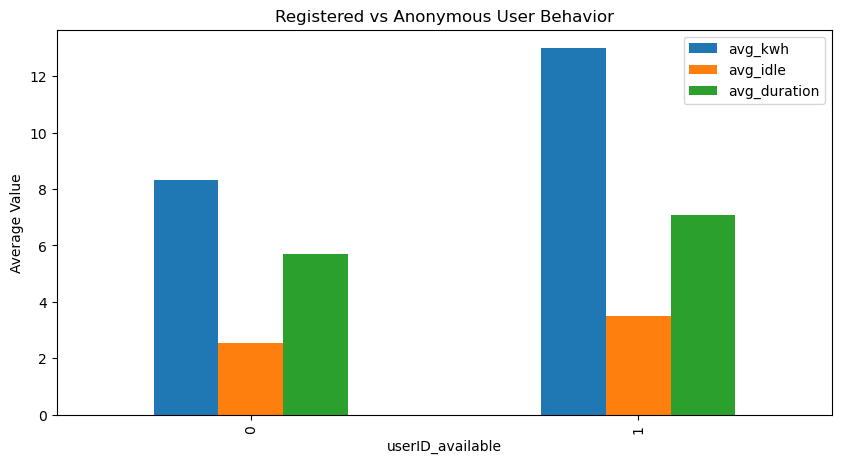

In [120]:
user_behavior.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title(
    'Registered vs Anonymous User Behavior'
)

plt.ylabel('Average Value')
plt.show()

### Interpretation

- Registered users exhibit significantly different charging behavior compared to anonymous users. On average, registered users consume approximately 13.0 kWh per session, compared to 8.3 kWh for anonymous users, representing nearly 56% higher energy consumption.

- Registered users also occupy chargers for longer periods, with an average session duration of 7.09 hours versus 5.71 hours for anonymous users. Additionally, their average idle time after charging completion is higher (3.51 hours compared to 2.54 hours).

- These findings suggest that registered users are likely more frequent or regular EV users who rely heavily on charging infrastructure. However, their longer idle occupancy may contribute disproportionately to charger congestion.

- From a tariff optimization perspective, user-type information may be a useful feature for demand forecasting and behavioral segmentation. Registered users may respond differently to dynamic pricing, idle fees, or charging incentives compared to occasional users.


# Key Audit Findings
1. Dataset quality is high, with negligible missing data and no duplicate sessions.
2. Charging demand is concentrated across a subset of stations.
3. Average idle occupancy (2.68 hours) is nearly as large as average active charging time (3.24 hours).
4. Several extreme idle-duration sessions indicate charger blocking behavior.
5. The dataset covers approximately eight months of operations, enabling robust temporal analysis.
6. A significant number of high-energy outlier sessions exist and should be considered during modeling.
7. Station-level utilization patterns suggest that dynamic pricing should be targeted rather than network-wide.

These findings create a direct bridge from the audit notebook to your later Demand Forecasting Agent, Pricing Agent, and Monitoring Agent..
